In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df=pd.read_csv('FDA_dugs.csv')
df.head()

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  str    
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  str    
 5   serious              528000 non-null  str    
 6   serious_flags        226894 non-null  str    
 7   is_fatal             528000 non-null  bool   
 8   is_hospitalized      528000 non-null  bool   
 9   is_life_threat       528000 non-null  bool   
 10  is_disabling         528000 non-null  bool   
 11  reactions            528000 non-null  str    
 12  primary_reaction     528000 non-null  str    
 13  reaction_outcomes    528000 non-null  str    
 14  patient_recovered    528000 non-null  bool   
 15  num_reactions        528000 

In [41]:
df.isnull().sum()

report_id                   0
receive_date                0
year                        0
month                       0
quarter                     0
serious                     0
serious_flags          301106
is_fatal                    0
is_hospitalized             0
is_life_threat              0
is_disabling                0
reactions                   0
primary_reaction            0
reaction_outcomes           0
patient_recovered           0
num_reactions               0
suspect_drug                0
brand_name                  0
drug_route                  0
drug_indication             0
manufacturer                0
pharm_class                 0
num_drugs                   0
drug_count_category         0
patient_age_years      151509
age_group                   0
patient_sex                 0
patient_weight_kg      379923
country                     0
report_age_days             0
dtype: int64

In [42]:
info=pd.DataFrame({
    'dtype':df.dtypes,
    'nulls':df.isnull().sum(),
    'uniques':df.nunique()

})
info

,dtype,nulls,uniques
report_id,int64,0,528000
receive_date,str,0,3974
year,int64,0,11
month,int64,0,12
quarter,str,0,44
serious,str,0,2
serious_flags,str,301106,31
is_fatal,bool,0,2
is_hospitalized,bool,0,2
is_life_threat,bool,0,2


In [73]:
fatal=(df['is_fatal']==True).sum()
fatal

np.int64(54301)

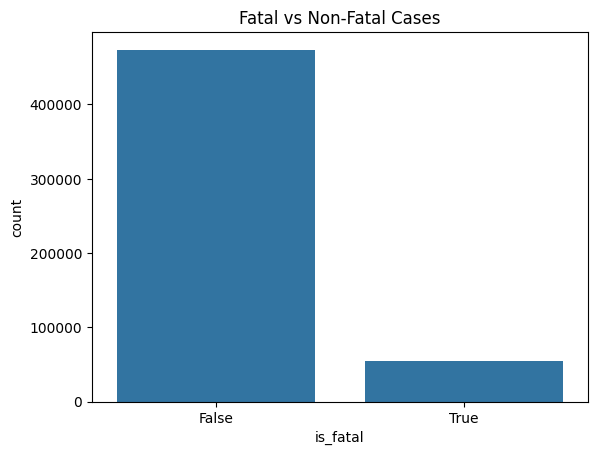

In [ ]:
sns.countplot(x='is_fatal', data=df)
plt.title("Fatal vs Non-Fatal Cases")
plt.show()


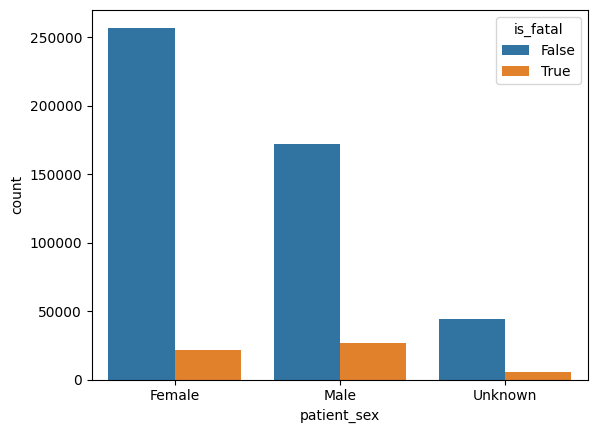

In [74]:
sns.countplot(x='patient_sex', hue='is_fatal', data=df)
plt.show()

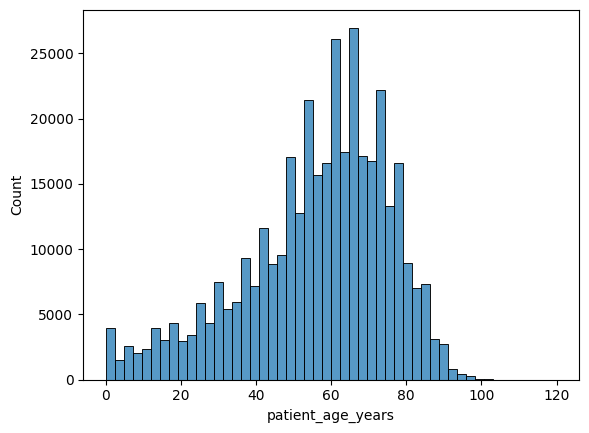

In [46]:
sns.histplot(df['patient_age_years'], bins=50)
plt.show()

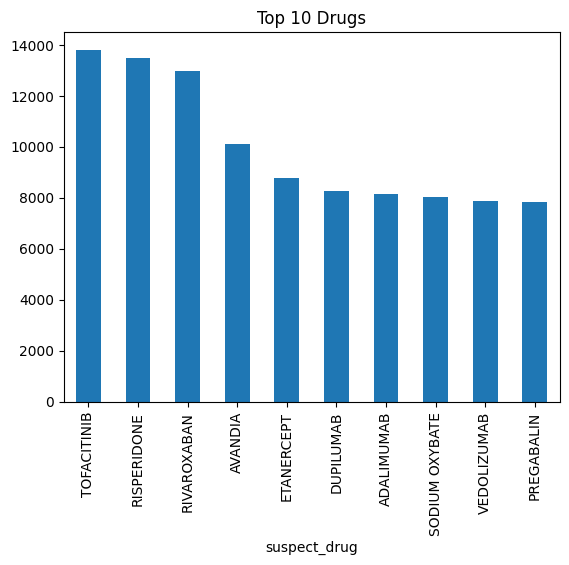

In [75]:


top_drugs = df['suspect_drug'].value_counts().head(10)

top_drugs.plot(kind='bar')
plt.title("Top 10 Drugs")
plt.show()



In [48]:
drop_cols = [
    'is_hospitalized',
    'is_life_threat',
    'is_disabling',
    'quarter',
    'serious',
    'serious_flags',
    'reactions',
    'brand_name',
    'drug_indication',
    'manufacturer',
    'primary_reaction',
    'reaction_outcomes',
    'patient_weight_kg',
    'patient_recovered',
    'receive_date',
    'report_id',
    'report_age_days'
]


In [ ]:
df.drop(drop_cols, axis = 1,inplace=True)

In [52]:
top_drugs = df['suspect_drug'].value_counts().head(50).index

df['suspect_drug'] = df['suspect_drug'].apply(
    lambda x: x if x in top_drugs else 'Other'
)

In [76]:
top_routes = df['drug_route'].value_counts().head(10).index

df['drug_route'] = df['drug_route'].apply(
    lambda x: x if x in top_routes else 'Other'
)


In [56]:
top_classes = df['pharm_class'].value_counts().head(20).index

df['pharm_class'] = df['pharm_class'].apply(
    lambda x: x if x in top_classes else 'Other'
)

In [57]:
top_countries = df['country'].value_counts().head(5).index

df['country'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

In [77]:
df['age_group'].unique()

<StringArray>
['Middle-Aged(41-65)',       'Adult(19-40)',            'Unknown',
      'Senior(66-80)',        'Teen(13-18)',        'Child(3-12)',
        'Infant(0-2)',       'Elderly(81+)']
Length: 8, dtype: str

In [61]:
df['age_group'] = df['age_group'].replace('Unknown', 'Adult(19-40)')

In [62]:
df = df[df['patient_age_years'] < 100]

In [63]:
age_map = {
    'Infant(0-2)': 1,
    'Child(3-12)': 8,
    'Teen(13-18)': 15,
    'Adult(19-40)': 30,
    'Middle-Aged(41-65)': 50,
    'Senior(66-80)': 70,
    'Elderly(81+)': 85
}

df['patient_age_years'] = df.apply(
    lambda row: age_map[row['age_group']]
    if pd.isnull(row['patient_age_years'])
    else row['patient_age_years'],
    axis=1
)

In [78]:
info = pd.DataFrame({'dtype': df.dtypes, 'nulls': df.isnull().sum(), 'unique': df.nunique()})
info

,dtype,nulls,unique
report_id,int64,0,528000
receive_date,str,0,3974
year,int64,0,11
month,int64,0,12
quarter,str,0,44
serious,str,0,2
serious_flags,str,301106,31
is_fatal,bool,0,2
is_hospitalized,bool,0,2
is_life_threat,bool,0,2


In [65]:
X = df.drop('is_fatal', axis = 1)
y = df['is_fatal']

In [66]:


X = pd.get_dummies(X, drop_first=True)
X.columns = (
    X.columns
    .str.replace(r'[\[\]<]', '', regex=True)
    .str.replace(' ', '_')
)



In [68]:

print(X.shape)
print(y.shape)



(376425, 102)
(376425,)


In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [70]:


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [80]:
from sklearn.metrics import classification_report, accuracy_score

models = {
    "RandomForest": rf,
}



y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.65).astype(int)
print("Accuracy Score :",accuracy_score(y_test, y_pred))
print("\nFull Report :\n",classification_report(y_test, y_pred))

Accuracy Score : 0.8680348010891944

Full Report :
               precision    recall  f1-score   support

       False       0.91      0.95      0.93     66569
        True       0.39      0.26      0.32      8716

    accuracy                           0.87     75285
   macro avg       0.65      0.60      0.62     75285
weighted avg       0.85      0.87      0.86     75285

